In [1]:
# EXPERIMENT 13: Fake News Classifier using NLP

# STEP 1: Load Required Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
# STEP 2: Load Dataset
url = "https://github.com/swarupjoys/eoai-I_lab/raw/refs/heads/main/ap_ts_news_dataset.csv"
df = pd.read_csv(url)

# Shuffle the data to ensure randomness
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [3]:
# STEP 3: Preview the Data
print("First 5 rows of data:")
print(df.head())

First 5 rows of data:
                                                text label
0  Free iPads and AirPods to every AP student wit...  FAKE
1  Hyderabad colleges to replace PT with ‘Yoga + ...  FAKE
2  Vizag to become the new IT capital of Andhra P...  REAL
3  Visakhapatnam cricket stadium gets world-class...  REAL
4  AP CM promises gold biscuit for every LIMAT st...  FAKE


In [4]:
# STEP 4: Student Task – Print basic stats
print("Dataset contains:", df.shape[0], "rows")
print("Label counts:\n", df['label'].value_counts())

# Replace the print above with:
# print("Dataset contains:", "_____")        # HINT: use df.shape[0]
# print("Label counts:\n", "_____")          # HINT: use df['label'].value_counts()

Dataset contains: 120 rows
Label counts:
 label
FAKE    60
REAL    60
Name: count, dtype: int64


In [5]:
# STEP 5: Student Task – Transform the labels
# Prepare Input (X) and Output (y)
X = df['text']                              # News headlines
y = df['label'].map({'FAKE': 0, 'REAL': 1}) # Encode: FAKE → 0, REAL → 1

In [6]:
# STEP 6: Split into Training and Testing Sets (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# STEP 7: Convert Text to Numbers using TF-IDF
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.5,
    ngram_range=(1, 2),
    max_features=1500
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Text vectorized using TF-IDF with bi-grams.")


Text vectorized using TF-IDF with bi-grams.


In [8]:
# STEP 8: Student Task – Create and Train the Classifier
# Fill in the blanks below to train a Naive Bayes model
model = ____________                # HINT: MultinomialNB()
model.fit(_____, _____)            # HINT: use X_train_vec and y_train

# (Instructor's version)
# model = MultinomialNB()
# model.fit(X_train_vec, y_train)


MultinomialNB()

In [9]:
# STEP 9: Make Predictions
y_pred = model.predict(X_test_vec)

In [10]:
# STEP 10: Evaluate the Model
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy of the model: {acc:.2f}")
print("Confusion Matrix:")
print(cm)


Accuracy of the model: 0.67
Confusion Matrix:
[[7 5]
 [3 9]]


In [11]:
# STEP 11: Student Task – Try Your Own Headline
# Replace the sample text with your own and test it!
# your_news = ["Aliens landed on the college roof last night."]
your_news = []
your_vec = vectorizer.transform(your_news)
your_pred = model.predict(your_vec)

print("Your Headline Prediction:", "REAL" if your_pred[0] == 1 else "FAKE")


Your Headline Prediction: FAKE


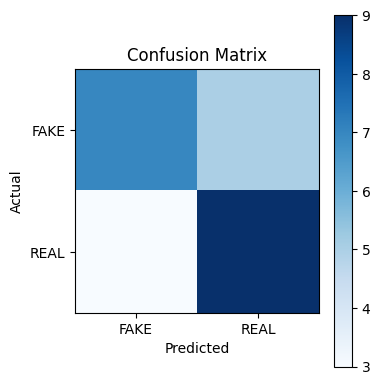

In [12]:
# STEP 12: Plot the Confusion Matrix
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xticks([0, 1], ["FAKE", "REAL"])
plt.yticks([0, 1], ["FAKE", "REAL"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()